In [3]:
import numpy as np
from numpy import sin, pi, exp
import matplotlib.pyplot as plt

# generate support data files for tutorial Southern Ocean Reentrant Channel
# hard-coded for eddying resolution: dx=dy=5 km (Cartesian)
# to exactly match the bathymetry and forcing in the coarse-res setup

# grid depths generated Using the hyperbolic tangent method of 
# Stewart et al. (2017) DOI: 10.1016/j.ocemod.2017.03.012
# to design an optimal grid.
# https://github.com/kialstewart/vertical_grid_for_ocean_models

dr = np.array([5.48716549,   6.19462098,   6.99291201,   7.89353689, \
               8.90937723,  10.05483267,  11.34595414,  12.80056778, \
              14.43837763,  16.28102917,  18.35210877,  20.67704362, \
              23.28285446,  26.1976981 ,  29.45012046,  33.06792588, \
              37.07656002,  41.496912  ,  46.34247864,  51.61592052, \
              57.30518684,  63.37960847,  69.78661289,  76.44996107, \
              83.27047568,  90.13003112,  96.89898027, 103.44631852, \
             109.65099217, 115.4122275 , 120.65692923, 125.34295968, \
             129.45821977, 133.01641219, 136.05088105, 138.60793752, \
             140.74074276, 142.50436556, 143.95220912, 145.133724  , \
             146.09317287, 146.86917206, 147.49475454, 147.99774783, \
             148.40131516, 148.72455653, 148.98310489, 149.18968055, \
             149.35458582])
nx = 600
ny = 1200
nr = len(dr)
rF = (np.insert(np.cumsum(dr), 0, 0)) # z-coordinates of vertical cell faces
z = np.diff(rF)/2 + rF[:-1]           # z-coordinates of vertical cell centers
H = -np.sum(dr)                       # max depth of vertical grid

# bathymetry -- flat bottom of depth H (m) with idealized mid-depth ridge
bump_max = 2000.   # peak height of ridge above flat bottom depth
bathy = H * np.ones([ny, nx])
bump=np.zeros([ny, nx])
# sinusoidal bump running N-S through middle of domain
# this is hard-coded for nx=200, ny=400 resolution
r1 = bump_max * sin(np.linspace(0,pi,310))
r2 = np.reshape((np.linspace(0,1,304)), [304,1])  # create linear ramp for center notch
bump[:,130:440] = r1
# linearly lower bump height toward center notch
bump[268:572,:] = bump[268:572,:] * np.flip(r2[:])
bump[608:912,:] = bump[608:912,:] * r2[:]
bump[571:609,:] = 0.0  # notch; in these latitude bands, contours of f/H are unblocked
bathy = bathy + bump;
bathy[0:10,:] = 0.                    # wall at southern boundary, matching coarse-res
bathy.astype('>f4').tofile('bathy.5km.bin')
print(bump.shape)

(1200, 600)


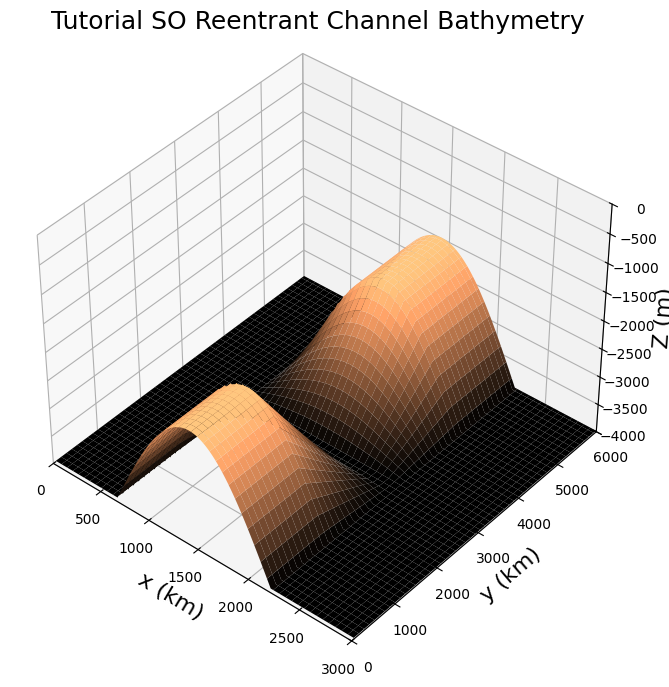

In [4]:
#plot bathymetry as 3D surface plot, as shown in fig 4.10
XC_1km = np.linspace(2500, 5997500, 1200)
YC_1km = np.linspace(2500, 2997500, 600)
YC,XC = np.meshgrid(YC_1km,XC_1km)
plt.figure(figsize=(10,8)) 
ax = plt.axes(projection='3d')
ax.plot_surface(YC[10:,:]/1000,XC[10:,:]/1000, bathy[10:,:], cmap='copper', edgecolor='none');
ax.view_init(40, -50)
ax.set_zlim(-4000,0)
ax.set_zlabel('Z (m)', fontsize=16)
ax.set_title('Tutorial SO Reentrant Channel Bathymetry', fontsize=18)
plt.xlabel('x (km)',fontsize=16); plt.ylabel('y (km)', fontsize=16)
plt.xlim(0,3000)
plt.ylim(0,6000);

In [ ]:
# zonal wind stress
import numpy as np
from numpy import sin, pi, exp
nx = 600
ny = 1200
taux_max = 0.2
taux = np.zeros([ny, nx])             # at (XG,YC) points
taux[5:1195,:] = np.reshape(taux_max * sin(np.linspace(0,pi,1190)), [1190,1])
taux.astype('>f4').tofile('zonal_wind.5km.bin')

In [ ]:
# Vertical interfaces (z_w) and centers (z_c), z<0 downward
z_w = np.concatenate(([0.0], -np.cumsum(dr)))        # interfaces: 0, -5.4, ...
z_c = 0.5 * (z_w[:-1] + z_w[1:])                       # cell centers
depth = -z_c                                           # positive downward
H = depth[-1]                                          # total depth (m)

# ----------------------------
# Meridional coordinate (y) for shaping profiles
# ----------------------------
# y index 0 = "south", ny-1 = "north"
j = np.arange(ny)
j_norm = j / (ny - 1.0)    # 0 (south) → 1 (north)

# ----------------------------
# Surface T, S profiles (SST, SSS)
# ----------------------------

T_south = -1.0
T_north =  6.0
S_south = 34.0
S_north = 35.0

# smooth tanh-like transition
def smooth_meridional_profile(val_south, val_north, j_norm, sharpness=6.0):
    """Sigmoidal transition from south to north."""
    # center the transition around mid-channel
    xi = (j_norm - 0.5) * sharpness
    w = 0.5 * (1.0 + np.tanh(xi))   # goes from 0 to 1
    return val_south * (1 - w) + val_north * w

T_surf = smooth_meridional_profile(T_south, T_north, j_norm, sharpness=5.0)  # (ny,)
S_surf = smooth_meridional_profile(S_south, S_north, j_norm, sharpness=5.0)  # (ny,)

# ----------------------------
# Mixed layer depth profile MLD(y)
# ----------------------------
# Southern Ocean-ish:
# Deep mixed layers in south (200-300 m), shallower north (50-80 m)
MLD_south = 250.0  # m
MLD_north =  60.0  # m
MLD = smooth_meridional_profile(MLD_south, MLD_north, j_norm, sharpness=4.0)  # (ny,)

# ----------------------------
# Deep water T, S and vertical decay scales
# ----------------------------
# Deep ACC waters: cold ~0.5 C, salty-ish ~34.7
T_deep = 0.5
S_deep = 34.7

h_T = 700.0   # e-folding scale for T below MLD (m)
h_S = 1000.0  # e-folding scale for S below MLD (m)

# ----------------------------
# Build 3D T and S fields
# ----------------------------
depth_3d   = depth[:, None, None]      # (nr,1,1)
MLD_3d     = MLD[None, :, None]        # (1,ny,1)
T_surf_3d  = T_surf[None, :, None]     # (1,ny,1)
S_surf_3d  = S_surf[None, :, None]     # (1,ny,1)

above_mld = depth_3d <= MLD_3d         # (nr,ny,1)
dz_below  = np.maximum(depth_3d - MLD_3d, 0.0)

# Below-MLD profiles toward deep values
T_below = T_deep + (T_surf_3d - T_deep) * np.exp(-dz_below / h_T)
S_below = S_deep + (S_surf_3d - S_deep) * np.exp(-dz_below / h_S)

# Combine: if above MLD -> surface value, else -> exponential profile
T_kj1 = np.where(above_mld, T_surf_3d, T_below)  # (nr,ny,1)
S_kj1 = np.where(above_mld, S_surf_3d, S_below)  # (nr,ny,1)

# Now replicate in x (zonal)
T_3D = np.repeat(T_kj1, nx, axis=2)              # (nr,ny,nx)
S_3D = np.repeat(S_kj1, nx, axis=2)              # (nr,ny,nx)

# Now replicate in x (zonal)
T_3D = np.repeat(T_3D[:, :, :1], nx, axis=2)
S_3D = np.repeat(S_3D[:, :, :1], nx, axis=2)

# ----------------------------
# RBCS masks (sponge layer at the north)
# ----------------------------
rbcs_mask_T = np.zeros((nr, ny, nx), dtype="float64")
rbcs_mask_S = np.zeros((nr, ny, nx), dtype="float64")

# no restoring in top cell (k=0), core model handles SST/SSS restoring
j_strong = 10   # last 10 grid rows: strong sponge
j_weak   = 20   # last 20 grid rows: weak sponge transition

# Strong sponge in northernmost 10 grid rows, below surface:
rbcs_mask_T[1:, -j_strong:, :] = 1.0
rbcs_mask_S[1:, -j_strong:, :] = 1.0

# Weaker sponge in next 10 grid rows:
rbcs_mask_T[1:, -j_weak:-j_strong, :] = 0.25
rbcs_mask_S[1:, -j_weak:-j_strong, :] = 0.25

# ----------------------------
# Write to binary files (big-endian float32)
# ----------------------------
T_3D.astype(">f4").tofile("temperature.5km.bin")
S_3D.astype(">f4").tofile("salinity.5km.bin")

# Surface restoring fields (SST/SSS) at C-points: 2D (ny, nx)
SST_relax = np.repeat(T_surf[:, None], nx, axis=1)   # (ny,nx)
SSS_relax = np.repeat(S_surf[:, None], nx, axis=1)

SST_relax.astype(">f4").tofile("SST_relax.5km.bin")
SSS_relax.astype(">f4").tofile("SSS_relax.5km.bin")

# RBCS masks:
rbcs_mask_T.astype(">f4").tofile("T_relax_mask.5km.bin")
rbcs_mask_S.astype(">f4").tofile("S_relax_mask.5km.bin")